In [24]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8")
%matplotlib inline

CSV_PATH = Path("benchmark_results.csv")
MATRICES_PATH = Path("last_run_matrices.json")

In [25]:
expected_columns = [
    "matrix_size",
    "serial_time_ms",
    "parallel_time_ms",
    "speedup",
    "num_servers",
    "timestamp",
]

if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Arquivo nao encontrado: {CSV_PATH.resolve()}"
    )

df = pd.read_csv(CSV_PATH)

missing = set(expected_columns) - set(df.columns)

if missing:
    raise ValueError(
        f"O CSV nao possui as colunas esperadas: {sorted(missing)}"
    )

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce",
)

df["_sort_key"] = df["matrix_size"].str.split("x").apply(
    lambda parts: sum(int(p) for p in parts)
)

df = df.sort_values(
    ["_sort_key", "timestamp"]
).drop(columns=["_sort_key"]).reset_index(drop=True)

print(f"Total de registros: {len(df)}")
print(f"Configurações de matriz: {df['matrix_size'].unique().tolist()}")
df

Total de registros: 11
Configurações de matriz: ['20x20x20', '50x30x70', '812x32x1164', '748x793x962', '126x1401x1267', '1718x617x813', '1236x532x1806', '687x1883x1054', '1973x1007x1199', '2000x2000x2000', '2000x1000x3000']


,matrix_size,serial_time_ms,parallel_time_ms,speedup,num_servers,timestamp
0,20x20x20,0.17,27.43,0.01,4,2026-05-24 13:59:52
1,50x30x70,0.05,25.56,0.00,4,2026-05-24 13:59:52
2,812x32x1164,21.80,18.03,1.21,4,2026-05-24 14:14:18
3,748x793x962,309.96,187.89,1.65,4,2026-05-24 14:14:15
4,126x1401x1267,794.05,304.92,2.60,4,2026-05-24 14:17:14
5,1718x617x813,477.72,199.96,2.39,4,2026-05-24 14:17:07
6,1236x532x1806,1464.04,693.86,2.11,4,2026-05-24 14:17:16
7,687x1883x1054,2101.90,1172.92,1.79,4,2026-05-24 14:14:18
8,1973x1007x1199,2850.48,1760.74,1.62,4,2026-05-24 14:17:12
9,2000x2000x2000,16076.83,5833.97,2.76,4,2026-05-24 14:00:14


In [27]:
summary = (
    df.groupby(
        [
            "matrix_size",
            "num_servers",
        ],
        as_index=False,
    )
    .agg(
        serial_time_ms=("serial_time_ms", "mean"),
        parallel_time_ms=("parallel_time_ms", "mean"),
        runs=("matrix_size", "count"),
    )
)

summary["speedup"] = (
    summary["serial_time_ms"] / summary["parallel_time_ms"]
)

summary["_sort_key"] = summary["matrix_size"].str.split("x").apply(
    lambda parts: sum(int(p) for p in parts)
)
summary = summary.sort_values("_sort_key", ascending=True).drop(columns=["_sort_key"]).reset_index(drop=True)

print(f"Resumo por configuração:")
summary

Resumo por configuração:


,matrix_size,num_servers,serial_time_ms,parallel_time_ms,runs,speedup
0,20x20x20,4,0.17,27.43,1,0.006198
1,50x30x70,4,0.05,25.56,1,0.001956
2,812x32x1164,4,21.80,18.03,1,1.209096
3,748x793x962,4,309.96,187.89,1,1.649689
4,126x1401x1267,4,794.05,304.92,1,2.604126
5,1718x617x813,4,477.72,199.96,1,2.389078
6,1236x532x1806,4,1464.04,693.86,1,2.109993
7,687x1883x1054,4,2101.90,1172.92,1,1.792023
8,1973x1007x1199,4,2850.48,1760.74,1,1.618910
9,2000x2000x2000,4,16076.83,5833.97,1,2.755727


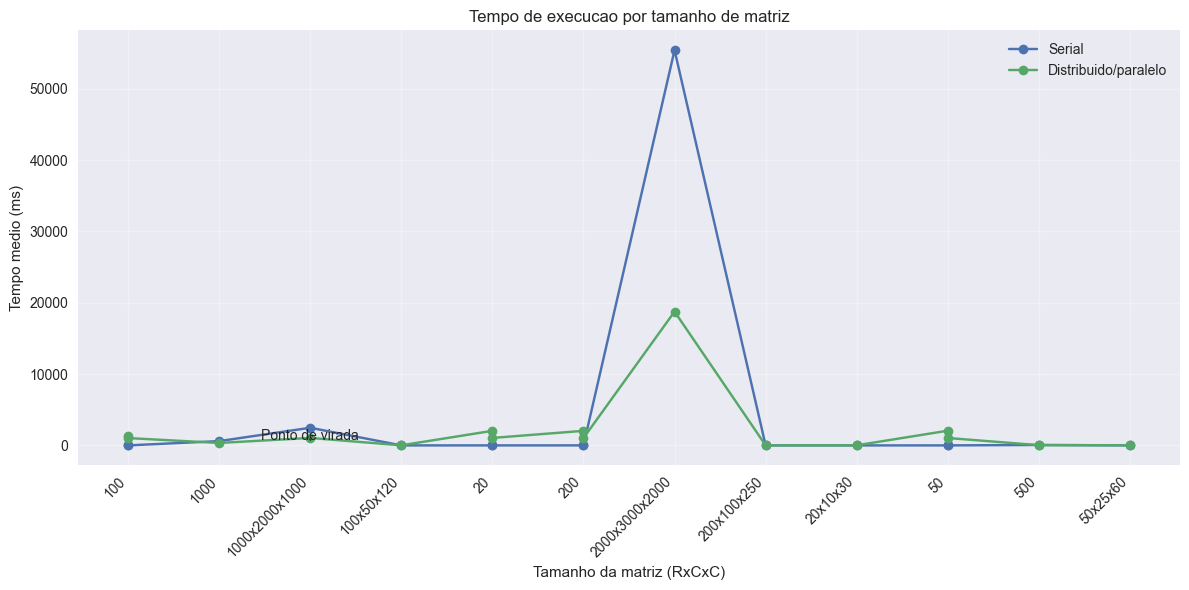

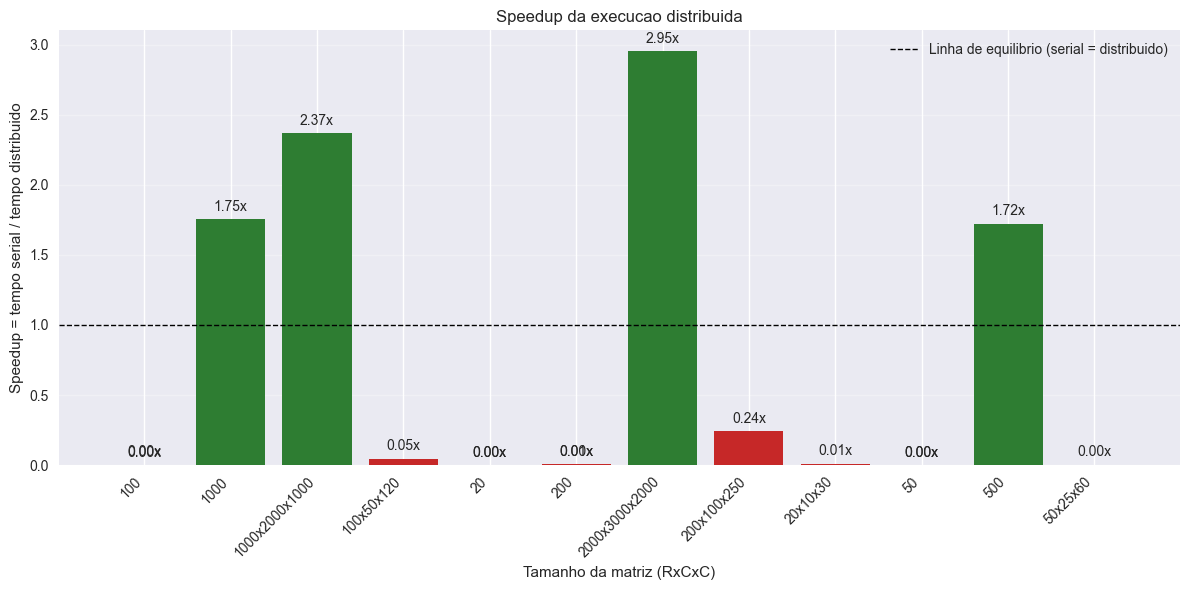

In [ ]:
if summary.empty:
    print("Sem dados para plotar.")
else:
    summary_plot = summary.copy()
    summary_plot["_sort_key"] = summary_plot["matrix_size"].str.split("x").apply(
    lambda parts: sum(int(p) for p in parts)
    )
    summary_plot = summary_plot.sort_values("_sort_key", ascending=True).drop(columns=["_sort_key"]).reset_index(drop=True)
    labels = summary_plot["matrix_size"].astype(str).tolist()
    serial_values = summary_plot["serial_time_ms"].to_numpy()
    parallel_values = summary_plot["parallel_time_ms"].to_numpy()
    speedup_values = summary_plot["speedup"].to_numpy()

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(
        labels,
        serial_values,
        marker="o",
        label="Serial",
    )

    ax.plot(
        labels,
        parallel_values,
        marker="o",
        label="Distribuido/paralelo",
    )

    crossing_candidates = np.where(parallel_values <= serial_values)[0]

    if len(crossing_candidates) > 0:
        turn_index = int(crossing_candidates[0])
    else:
        turn_index = int(np.argmin(np.abs(serial_values - parallel_values)))

    turn_y = max(serial_values[turn_index], parallel_values[turn_index])

    ax.annotate(
        "Ponto de virada",
        xy=(turn_index, turn_y),
        xytext=(turn_index, turn_y * 1.15 if turn_y > 0 else 1),
        arrowprops={"arrowstyle": "->", "color": "black"},
        ha="center",
    )

    ax.set_title("Tempo de execucao por tamanho de matriz")
    ax.set_xlabel("Tamanho da matriz (RxCxC)")
    ax.set_ylabel("Tempo medio (ms)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 6))

    bar_colors = [
        "#2e7d32" if speedup >= 1.0 else "#c62828"
        for speedup in speedup_values
    ]

    bars = ax.bar(
        labels,
        speedup_values,
        color=bar_colors,
    )

    ax.axhline(
        1,
        color="black",
        linewidth=1,
        linestyle="--",
        label="Linha de equilibrio (serial = distribuido)",
    )

    for bar, speedup in zip(bars, speedup_values):
        ax.annotate(
            f"{speedup:.2f}x",
            xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
        )

    ax.set_title("Speedup da execucao distribuida")
    ax.set_xlabel("Tamanho da matriz (RxCxC)")
    ax.set_ylabel("Speedup = tempo serial / tempo distribuido")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [5]:
import sys

class MatrixMetadataCache:
    """Cache de metadados de matrizes sem carregar os dados inteiros na memoria."""
    
    def __init__(self, json_path):
        self.json_path = Path(json_path)
        self.metadata = {}
        self._scan_metadata()
    
    def _scan_metadata(self):
        """Escaneia o JSON e extrai apenas metadados (tamanhos, nomes)."""
        print("[CACHE] Escaneando metadados das matrizes...")
        
        if not self.json_path.exists():
            print(f"Arquivo nao encontrado: {self.json_path}")
            return
        
        try:
            with open(self.json_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            matrices = data.get('matrices', {})
            
            for config_key, config_data in matrices.items():
                try:
                    rows_a = len(config_data.get('A', []))
                    cols_a = len(config_data['A'][0]) if rows_a > 0 else 0
                    
                    rows_b = len(config_data.get('B', []))
                    cols_b = len(config_data['B'][0]) if rows_b > 0 else 0
                    
                    rows_c = len(config_data.get('C', []))
                    cols_c = len(config_data['C'][0]) if rows_c > 0 else 0
                    
                    self.metadata[config_key] = {
                        'config': config_key,
                        'dims_A': (rows_a, cols_a),
                        'dims_B': (rows_b, cols_b),
                        'dims_C': (rows_c, cols_c),
                        'size_mb': self._estimate_size(rows_a, cols_a, rows_b, cols_b, rows_c, cols_c),
                    }
                except Exception as e:
                    print(f"[ERRO] Ao processar {config_key}: {e}")
        
        except Exception as e:
            print(f"[ERRO] Ao ler JSON: {e}")
        
        print(f"[CACHE] {len(self.metadata)} matrizes indexadas")
    
    @staticmethod
    def _estimate_size(rows_a, cols_a, rows_b, cols_b, rows_c, cols_c):
        """Estima tamanho em MB (int32 = 4 bytes)."""
        total_elements = (rows_a * cols_a) + (rows_b * cols_b) + (rows_c * cols_c)
        return round((total_elements * 4) / (1024 * 1024), 2)
    
    def get_matrix_lazy(self, config_key):
        """Carrega apenas uma matriz especifica (lazy loading)."""
        print(f"[CARREGANDO] {config_key}...")
        
        try:
            with open(self.json_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            matrices = data.get('matrices', {})
            
            if config_key in matrices:
                item = matrices[config_key]
                return {
                    'A': np.array(item['A']),
                    'B': np.array(item['B']),
                    'C': np.array(item['C']),
                    'partial_results': item.get('partial_results', []),
                }
            else:
                print(f"[ERRO] Configuracao {config_key} nao encontrada")
                return None
        
        except Exception as e:
            print(f"[ERRO] Ao carregar {config_key}: {e}")
            return None
    
    def list_matrices(self, filter_size_mb=None):
        """Lista matrizes com opcao de filtro por tamanho."""
        print("\n" + "="*90)
        print("LISTA DE MATRIZES DISPONIVEIS")
        print("="*90)
        
        items = list(self.metadata.items())
        
        if filter_size_mb is not None:
            items = [(k, v) for k, v in items if v['size_mb'] <= filter_size_mb]
            print(f"Filtrado por tamanho <= {filter_size_mb}MB\n")
        
        for config_key, meta in items:
            dims_a, dims_b, dims_c = meta['dims_A'], meta['dims_B'], meta['dims_C']
            print(
                f"Config: {config_key:20s} | "
                f"A:{dims_a[0]:6d}x{dims_a[1]:<6d} x "
                f"B:{dims_b[0]:6d}x{dims_b[1]:<6d} = "
                f"C:{dims_c[0]:6d}x{dims_c[1]:<6d} | "
                f"Tamanho: {meta['size_mb']:10.2f} MB"
            )
        
        print("="*90)
        print(f"Total: {len(items)} matrizes\n")
        
        return dict(items)


if not MATRICES_PATH.exists():
    print(
        "Arquivo last_run_matrices.json nao encontrado. "
        "Execute o Client.py primeiro."
    )
else:
    cache = MatrixMetadataCache(MATRICES_PATH)
    
    print(f"\nMemoria usada por este notebook: {sys.getsizeof(cache) / 1024 / 1024:.2f} MB")
    print(f"(Cache de metadados - NENHUMA matriz carregada ainda)")

[CACHE] Escaneando metadados das matrizes...
[CACHE] 6 matrizes indexadas

Memoria usada por este notebook: 0.00 MB
(Cache de metadados - NENHUMA matriz carregada ainda)


In [6]:
def visualizar_matriz(cache, config_key, max_rows=5, max_cols=5):
    """Visualiza uma matriz especifica."""
    
    matrices = cache.get_matrix_lazy(config_key)
    
    if matrices is None:
        return
    
    meta = cache.metadata[config_key]
    dims_a, dims_b, dims_c = meta['dims_A'], meta['dims_B'], meta['dims_C']
    
    print(f"\nMatriz {config_key} ({meta['size_mb']:.2f} MB)")
    print(f"Dimensoes: A={dims_a}, B={dims_b}, C={dims_c}")
    print()
    
    print("Matriz A (primeiras 5x5):")
    preview_a = matrices['A'][:max_rows, :max_cols]
    print(preview_a)
    print()
    
    print("Matriz B (primeiras 5x5):")
    preview_b = matrices['B'][:max_rows, :max_cols]
    print(preview_b)
    print()
    
    print(f"Resultados parciais dos servidores:")
    for partial in matrices['partial_results']:
        server_num = partial['server']
        rows, cols = partial['rows'], partial['cols']
        print(f"  Servidor {server_num}: {rows}x{cols}")
    print()
    
    print("Matriz C final (primeiras 5x5):")
    preview_c = matrices['C'][:max_rows, :max_cols]
    print(preview_c)
    print()
    
    del matrices
    print("[OK] Matriz descarregada da memoria\n")


print("\n" + "="*90)
print("OPCOES DE VISUALIZACAO")
print("="*90)
print()
print("1. Ver TODAS as matrizes (com informacoes de tamanho):")
print("   todas = cache.list_matrices()")
print()
print("2. Ver apenas matrizes pequenas (< 100 MB):")
print("   pequenas = cache.list_matrices(filter_size_mb=100)")
print()
print("3. Visualizar uma matriz especifica:")
print("   visualizar_matriz(cache, '20x10x30')")
print()
print("4. Listar todos os metadados:")
print("   for key, meta in cache.metadata.items():")
print("       print(f'{key}: {meta}')")
print()
print("="*90)


OPCOES DE VISUALIZACAO

1. Ver TODAS as matrizes (com informacoes de tamanho):
   todas = cache.list_matrices()

2. Ver apenas matrizes pequenas (< 100 MB):
   pequenas = cache.list_matrices(filter_size_mb=100)

3. Visualizar uma matriz especifica:
   visualizar_matriz(cache, '20x10x30')

4. Listar todos os metadados:
   for key, meta in cache.metadata.items():
       print(f'{key}: {meta}')



In [7]:
if summary.empty:
    print("Ainda nao ha resultados para analisar.")
else:
    print("\n" + "="*90)
    print("RESUMO DOS BENCHMARKS")
    print("="*90)
    
    summary_sorted = summary.sort_values("matrix_size", ascending=True)
    for row in summary_sorted.itertuples(index=False):
        print(
            f"Config {str(row.matrix_size):20s} "
            f"com {int(row.num_servers)} servidor(es): "
            f"serial={row.serial_time_ms:10.2f} ms, "
            f"distribuido={row.parallel_time_ms:10.2f} ms, "
            f"speedup={row.speedup:6.2f}x "
            f"({int(row.runs)} execucao/execucoes)"
        )

    print()
    best = summary.loc[summary["speedup"].idxmax()]
    print(
        f"Melhor speedup observado: {best['speedup']:.2f}x "
        f"para config {best['matrix_size']}"
    )
    print("="*90)


RESUMO DOS BENCHMARKS
Config 100                  com 2 servidor(es): serial=      0.48 ms, distribuido=   1379.71 ms, speedup=  0.00x (3 execucao/execucoes)
Config 100                  com 4 servidor(es): serial=      1.40 ms, distribuido=   1029.83 ms, speedup=  0.00x (4 execucao/execucoes)
Config 1000                 com 4 servidor(es): serial=    603.04 ms, distribuido=    343.75 ms, speedup=  1.75x (2 execucao/execucoes)
Config 1000x2000x1000       com 4 servidor(es): serial=   2474.66 ms, distribuido=   1045.74 ms, speedup=  2.37x (1 execucao/execucoes)
Config 100x50x120           com 4 servidor(es): serial=      0.64 ms, distribuido=     13.67 ms, speedup=  0.05x (1 execucao/execucoes)
Config 20                   com 2 servidor(es): serial=      0.15 ms, distribuido=   2045.02 ms, speedup=  0.00x (2 execucao/execucoes)
Config 20                   com 4 servidor(es): serial=      0.06 ms, distribuido=   1048.75 ms, speedup=  0.00x (4 execucao/execucoes)
Config 200               